
# Tumor Classification — **PyTorch** End-to-End (Converted from TensorFlow)
This notebook replaces all TensorFlow/Keras code with a **pure PyTorch** pipeline while keeping your dataset structure and hyperparameters intact.

**Includes:**
- Reproducible config
- Data loaders with `torchvision.datasets.ImageFolder`
- Train/val loop with metrics (loss, accuracy)
- Test evaluation
- Confusion matrix report
- Model checkpointing & resume
- Inference helper (`predict_image`)


In [5]:
# === Config ===
import os, random, math, numpy as np, torch

# Detected or fallback values (auto-extracted from your original notebook)
TRAIN_DIR = r"data_merged/train"
VAL_DIR   = r"data_merged/val"
TEST_DIR  = r"data_merged/test"
IMG_SIZE  = (224, 224)  # (width, height)
BATCH_SIZE = 32
EPOCHS     = 20
LR         = 0.001
NUM_WORKERS = 2

# If you know your class names explicitly, set them here to ensure stable ordering.
# Otherwise ImageFolder will infer from subfolder names (alphabetical).
CLASS_NAMES = []

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
print("CUDA available:", torch.cuda.is_available())

# For reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# Create output directory
OUTPUT_DIR = "outputs_pytorch"
os.makedirs(OUTPUT_DIR, exist_ok=True)


Using device: cuda
CUDA available: True


In [6]:
# === Data: Datasets & Dataloaders ===
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from collections import Counter

# Basic augmentations for train; only resize+center-crop for val/test
# Note: torchvision uses (H, W) when specifying sizes for transforms like Resize
H, W = IMG_SIZE[1], IMG_SIZE[0]

train_tfms = transforms.Compose([
    transforms.Resize((H, W)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize((H, W)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tfms)
val_ds   = datasets.ImageFolder(VAL_DIR,   transform=eval_tfms) if os.path.isdir(VAL_DIR) else None
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=eval_tfms) if os.path.isdir(TEST_DIR) else None

# Infer class names if not provided
if not CLASS_NAMES:
    CLASS_NAMES = train_ds.classes
num_classes = len(CLASS_NAMES)
print("Classes:", CLASS_NAMES)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) if val_ds else None
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) if test_ds else None

# Report class counts (train)
targets = [y for _, y in train_ds.samples]
counts = Counter(targets)
print("Train class distribution (index:count):", counts)


Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Train class distribution (index:count): Counter({0: 2175, 1: 1407, 3: 1364, 2: 1362})


In [7]:
# === Model ===
import torch.nn as nn
import torch

# Simple, strong baseline using a torchvision backbone (e.g., ResNet18)
# You can switch to resnet34/resnet50/efficientnet_v2 etc.
from torchvision.models import resnet18

def build_model(num_classes):
    model = resnet18(weights="IMAGENET1K_V1")
    # Replace the final FC layer
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.2),
        nn.Linear(in_features, num_classes)
    )
    return model

model = build_model(num_classes).to(DEVICE)
print(model)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [8]:
# === Training & Validation Loop ===
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.auto import tqdm
import math

criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

def accuracy_from_logits(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

def run_epoch(loader, train=True):
    if loader is None:
        return math.nan, math.nan
    model.train(train)
    total_loss, total_acc, n = 0.0, 0.0, 0
    for x, y in tqdm(loader, leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        if train:
            optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        if train:
            loss.backward()
            optimizer.step()
        acc = accuracy_from_logits(logits, y)
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_acc  += acc * bs
        n += bs
    return total_loss / max(n,1), total_acc / max(n,1)

best_val_acc = -1.0
ckpt_path = os.path.join(OUTPUT_DIR, "best_model.pt")

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc     = run_epoch(val_loader, train=False) if val_loader else (math.nan, math.nan)

    scheduler.step()
    history["train_loss"].append(train_loss); history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss);     history["val_acc"].append(val_acc)

    msg = f"Epoch {epoch:03d}/{EPOCHS} | train_loss={train_loss:.4f} acc={train_acc:.4f}"
    if val_loader: msg += f" | val_loss={val_loss:.4f} acc={val_acc:.4f}"
    print(msg)

    if val_loader and val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({"model_state": model.state_dict(),
                    "classes": CLASS_NAMES,
                    "img_size": IMG_SIZE}, ckpt_path)
        print(f"✅ Saved new best model to: {ckpt_path} (val_acc={val_acc:.4f})")


C:\Users\pavan\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch 001/20 | train_loss=0.3661 acc=0.8676 | val_loss=0.2939 acc=0.9153
✅ Saved new best model to: outputs_pytorch\best_model.pt (val_acc=0.9153)


Epoch 002/20 | train_loss=0.2225 acc=0.9236 | val_loss=0.1551 acc=0.9545
✅ Saved new best model to: outputs_pytorch\best_model.pt (val_acc=0.9545)


Epoch 003/20 | train_loss=0.1495 acc=0.9471 | val_loss=0.1828 acc=0.9587
✅ Saved new best model to: outputs_pytorch\best_model.pt (val_acc=0.9587)


Epoch 004/20 | train_loss=0.1255 acc=0.9586 | val_loss=0.1471 acc=0.9525


...

Epoch 016/20 | train_loss=0.0074 acc=0.9976 | val_loss=0.0996 acc=0.9793


Epoch 017/20 | train_loss=0.0052 acc=0.9979 | val_loss=0.0882 acc=0.9814


Epoch 018/20 | train_loss=0.0041 acc=0.9987 | val_loss=0.0835 acc=0.9814


Epoch 019/20 | train_loss=0.0038 acc=0.9989 | val_loss=0.0833 acc=0.9835


Epoch 020/20 | train_loss=0.0036 acc=0.9987 | val_loss=0.0838 acc=0.9814


Loaded best checkpoint for evaluation.
=== Val Classification Report ===
              precision    recall  f1-score   support

      glioma       0.97      0.94      0.95        62
  meningioma       0.98      1.00      0.99        89
    no_tumor       0.90      0.93      0.92        29
   pituitary       1.00      1.00      1.00       304

    accuracy                           0.99       484
   macro avg       0.96      0.97      0.96       484
weighted avg       0.99      0.99      0.99       484



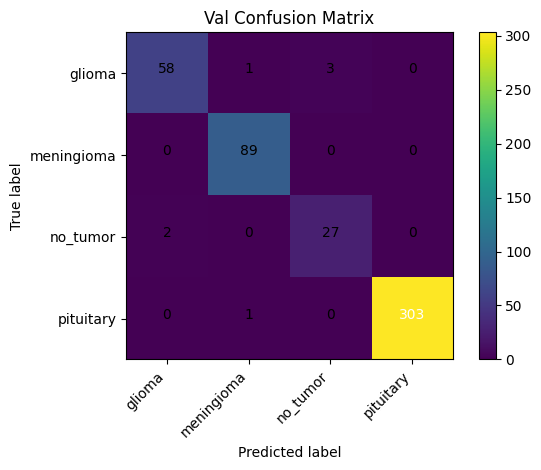

=== Test Classification Report ===
              precision    recall  f1-score   support

      glioma       1.00      0.95      0.97        91
  meningioma       0.97      1.00      0.98       139
    no_tumor       0.99      0.99      0.99       340
   pituitary       0.99      0.98      0.99       108

    accuracy                           0.99       678
   macro avg       0.99      0.98      0.98       678
weighted avg       0.99      0.99      0.99       678



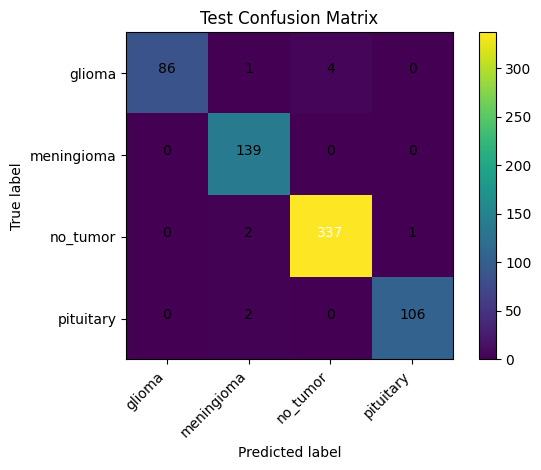

In [9]:
# === Evaluation on Test Set ===
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import itertools
import matplotlib.pyplot as plt

def evaluate(loader, split="Test"):
    if loader is None:
        print(f"No {split} loader configured.")
        return
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            logits = model(x)
            preds = logits.argmax(dim=1).cpu().numpy().tolist()
            all_preds += preds
            all_true  += y.numpy().tolist()
    print(f"=== {split} Classification Report ===")
    print(classification_report(all_true, all_preds, target_names=CLASS_NAMES))
    cm = confusion_matrix(all_true, all_preds)

    # Plot CM (single plot, default colors, no styles)
    fig = plt.figure()
    plt.imshow(cm, interpolation='nearest')
    plt.title(f'{split} Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(CLASS_NAMES))
    plt.xticks(tick_marks, CLASS_NAMES, rotation=45, ha='right')
    plt.yticks(tick_marks, CLASS_NAMES)
    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

# Load best checkpoint if available
if os.path.exists(os.path.join(OUTPUT_DIR, "best_model.pt")):
    ckpt = torch.load(os.path.join(OUTPUT_DIR, "best_model.pt"), map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])
    print("Loaded best checkpoint for evaluation.")

evaluate(val_loader, split="Val")
evaluate(test_loader, split="Test")


In [11]:
# === Resume Training (optional) ===
RESUME = False
CKPT_PATH = os.path.join(OUTPUT_DIR, "best_model.pt")

if RESUME and os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])
    print("Resumed model weights from:", CKPT_PATH)
else:
    print("Resume disabled or checkpoint not found.")    


Resume disabled or checkpoint not found.


In [12]:
# === Export: Save final scripted model (optional) ===
script_path = os.path.join(OUTPUT_DIR, "model_scripted.pt")
model_scripted = torch.jit.script(model.cpu())
model_scripted.save(script_path)
print("Saved TorchScript model to:", script_path)


Saved TorchScript model to: outputs_pytorch\model_scripted.pt
